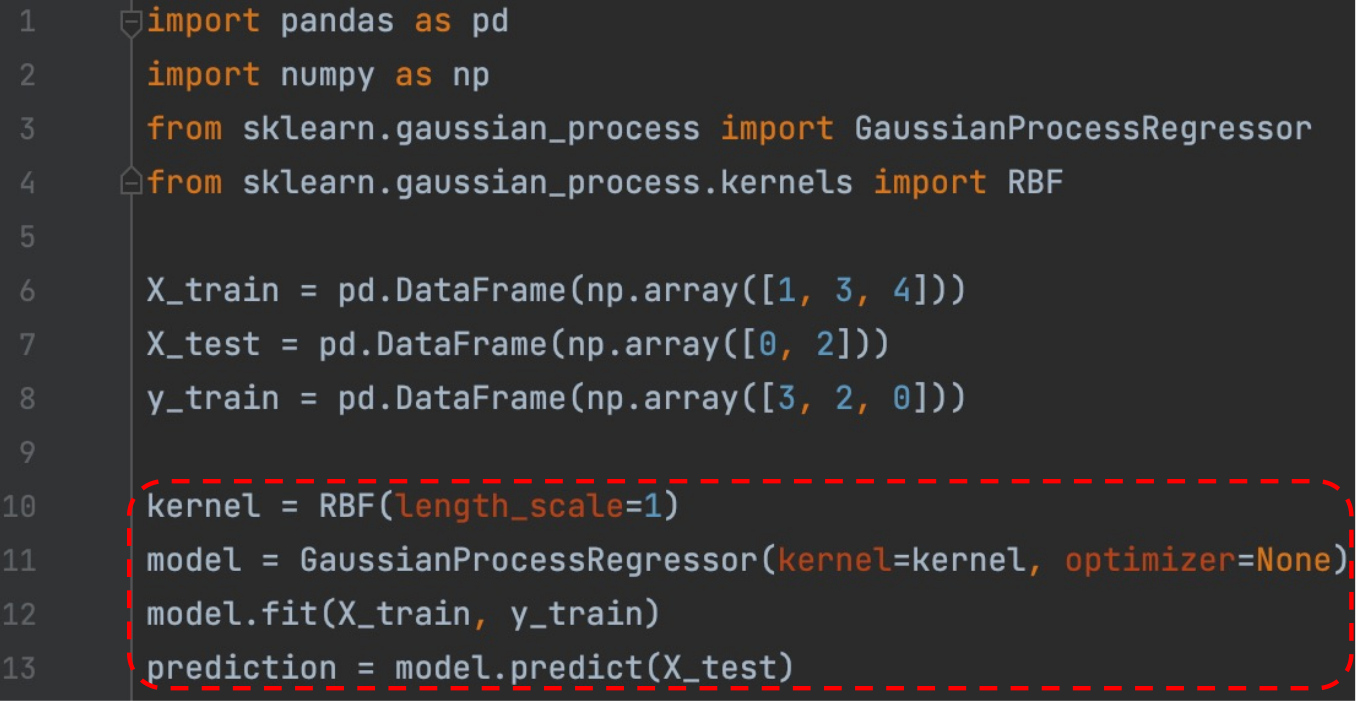

## A simple GPR example 

To get an initial idea of GPR modeling, let's start with a simple example. Type the 13 line codes from the pic and plot the training data and testing data. You should be able to finish it within 5 minutes.
(This example is taken from M. Thode, "Near-field Prediction of Coils for Wireless Power Transfer using Gaussian Process Regression",Bachelor Thesis, TUHH, 2022)

[1.64385275 2.98644978]


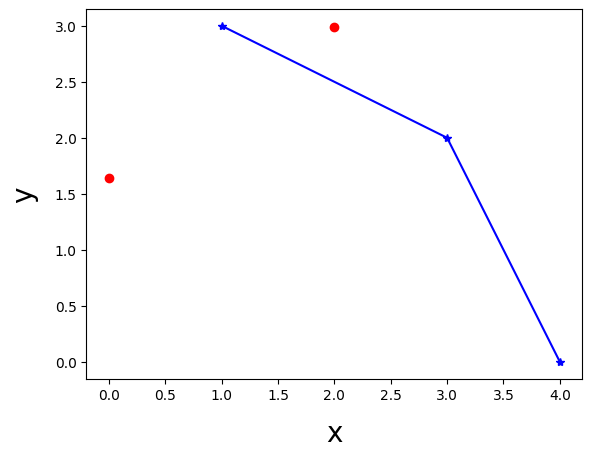

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# training and testing data
X_train = pd.DataFrame(np.array([1, 3, 4]))
X_test = pd.DataFrame(np.array([0, 2]))
y_train = pd.DataFrame(np.array([3, 2, 0]))

kernel = RBF(length_scale=1)
model = GaussianProcessRegressor(kernel=kernel, optimizer=None)
model.fit(X_train, y_train)
prediction = model.predict(X_test)

print(prediction)

# Plot the curve

fig = plt.figure("A simple GPR example")
ax1 = fig.add_subplot(111)
ax1.plot(X_train, y_train, 'b*-',X_test, prediction,'ro')
plt.xlabel(r"x", fontsize=20, labelpad=12)
plt.ylabel(r"y", fontsize=20, labelpad=12)
plt.show()


Now increase the number of testing points upto 20, see how the prediction looks like.

[ 1.41440984e-26  8.68244132e-22  1.75993133e-17  1.17797717e-13
  2.60354661e-10  1.90012243e-07  4.57919245e-05  3.64430499e-03
  9.58259902e-02  8.36010197e-01  2.49962029e+00  3.12110236e+00
  2.51855696e+00  6.06305929e-01 -6.52153923e-01 -2.73104874e-01
 -2.69090551e-02 -8.06962798e-04 -7.78906378e-06 -2.46127216e-08]


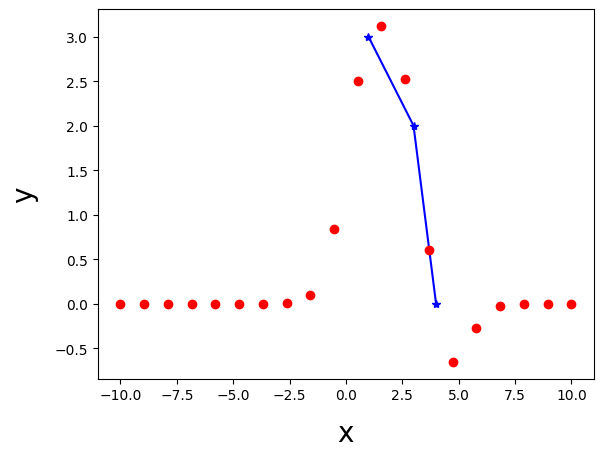

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# training and testing data
X_train = pd.DataFrame(np.array([1, 3, 4]))
X_test = pd.DataFrame(np.array(np.linspace(-10, 10, 20)))
y_train = pd.DataFrame(np.array([3, 2, 0]))

kernel = RBF(length_scale=1)
model = GaussianProcessRegressor(kernel=kernel, optimizer=None)
model.fit(X_train, y_train)
prediction = model.predict(X_test)

print(prediction)

# Plot the curve

fig = plt.figure("A simple GPR example")
ax1 = fig.add_subplot(111)
ax1.plot(X_train, y_train, 'b*-',X_test, prediction,'ro')
plt.xlabel(r"x", fontsize=20, labelpad=12)
plt.ylabel(r"y", fontsize=20, labelpad=12)
plt.show()

Now change the length_scale of RBF kernel function to be other value, see how the prediction changes.

[ 3.79626470e-12  5.09824918e-10  4.18472809e-08  2.09979951e-06
  6.44408590e-05  1.21098338e-03  1.39760799e-02  9.97537552e-02
  4.47136695e-01  1.29562931e+00  2.52009211e+00  3.31470608e+00
  2.62908398e+00  6.03066784e-01 -9.38144392e-01 -9.82018709e-01
 -4.26023319e-01 -1.00026102e-01 -1.35792120e-02 -1.09407651e-03]


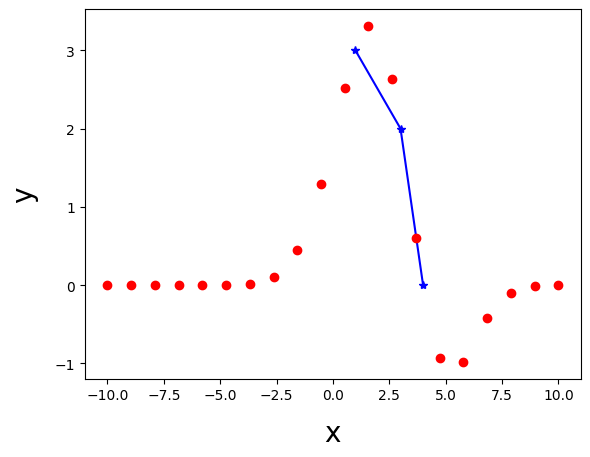

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# training and testing data
X_train = pd.DataFrame(np.array([1, 3, 4]))
X_test = pd.DataFrame(np.array(np.linspace(-10, 10, 20)))
y_train = pd.DataFrame(np.array([3, 2, 0]))

kernel = RBF(length_scale=1.5)
model = GaussianProcessRegressor(kernel=kernel, optimizer=None)
model.fit(X_train, y_train)
prediction = model.predict(X_test)

print(prediction)

# Plot the curve

fig = plt.figure("A simple GPR example")
ax1 = fig.add_subplot(111)
ax1.plot(X_train, y_train, 'b*-',X_test, prediction,'ro')
plt.xlabel(r"x", fontsize=20, labelpad=12)
plt.ylabel(r"y", fontsize=20, labelpad=12)
plt.show()

## An advanced GPR example

Now let's run another GPR example taken from "An Intuitive Tutorial to Gaussian Processes Regression", Wang, Jie. arXiv preprint arXiv:2009.10862 (2020).

In [4]:
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

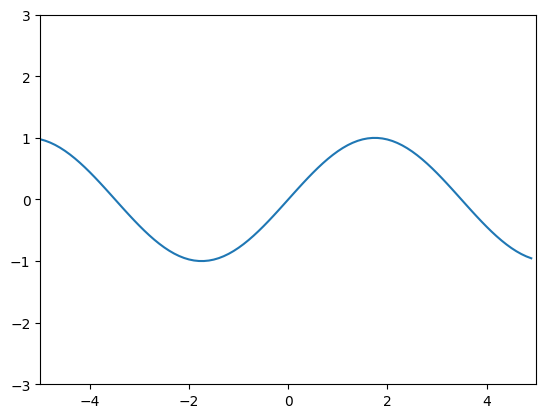

In [5]:
# This is the true unknown function we are trying to approximate
f = lambda x: np.sin(0.9*x).flatten()
#f = lambda x: (0.25*(x**2)).flatten()
x = np.arange(-5, 5, 0.1)

plt.plot(x, f(x))
plt.axis([-5, 5, -3, 3])
plt.show()

In [6]:
# Define the kernel
def kernel(a, b):
    kernelParameter_l = 0.1
    kernelParameter_sigma = 1.0
    sqdist = np.sum(a**2,axis=1).reshape(-1,1) + np.sum(b**2,1) - 2*np.dot(a, b.T)
    # np.sum( ,axis=1) means adding all elements columnly; .reshap(-1, 1) add one dimension to make (n,) become (n,1)
    return kernelParameter_sigma*np.exp(-.5 * (1/kernelParameter_l) * sqdist)

We use a general Squared Exponential Kernel, also called Radial Basis Function Kernel or Gaussian Kernel:

$$
\kappa(\mathbf{x}_i,\mathbf{x}_j) = \sigma_f^2 \exp(-\frac{1}{2l^2}
  (\mathbf{x}_i - \mathbf{x}_j)^T
  (\mathbf{x}_i - \mathbf{x}_j))
$$

where $\sigma_f$ and $l$ are hyperparameters. More information about the hyperparameters can be found after the codes. 

In the following, the code becomes lengthy because more math is involved. The algorithm executed follows 

The textbook [GPML](http://gaussianprocess.org/gpml/chapters/RW.pdf), P19. [1]

<img src="https://github.com/jwangjie/Gaussian-Process-be-comfortable-using-it/blob/master/img/gp1.png?raw=1" width="600"/> 

Dr. Nando de Freitas, [Introduction to Gaussian processes](https://youtu.be/4vGiHC35j9s). [6]

<img src="https://github.com/jwangjie/Gaussian-Process-be-comfortable-using-it/blob/master/img/gp.png?raw=1" width="500"/>

**The algorithm is complicated and you can simply skip it at the moment.**

200
20


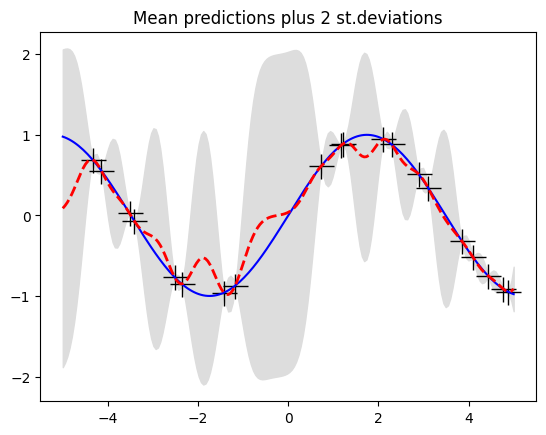

In [7]:
# Sample some input points and noisy versions of the function evaluated at
# these points. 
N = 20         # number of existing observation points (training points).
n = 200        # number of test points.
print(n)
print(N)
s = 0.00005    # noise variance.

X = np.random.uniform(-5, 5, size=(N,1))     # N training points 
y = f(X) + s*np.random.randn(N)

K = kernel(X, X)
L = np.linalg.cholesky(K + s*np.eye(N))     # line 1 

# points we're going to make predictions at.
Xtest = np.linspace(-5, 5, n).reshape(-1,1)

# compute the mean at our test points.
Lk = np.linalg.solve(L, kernel(X, Xtest))   # k_star = kernel(X, Xtest), calculating v := l\k_star
mu = np.dot(Lk.T, np.linalg.solve(L, y))    # \alpha = np.linalg.solve(L, y) 

# compute the variance at our test points.
K_ = kernel(Xtest, Xtest)                  # k(x_star, x_star)        
s2 = np.diag(K_) - np.sum(Lk**2, axis=0)   
s = np.sqrt(s2)

# PLOTS:
plt.figure(1)
plt.clf()
plt.plot(X, y, 'k+', ms=18)
plt.plot(Xtest, f(Xtest), 'b-')
plt.gca().fill_between(Xtest.flat, mu-2*s, mu+2*s, color="#dddddd")
plt.plot(Xtest, mu, 'r--', lw=2)
#plt.savefig('predictive.png', bbox_inches='tight', dpi=300)
plt.title('Mean predictions plus 2 st.deviations')
plt.show()
#plt.axis([-5, 5, -3, 3])


200
20


<Figure size 640x480 with 0 Axes>

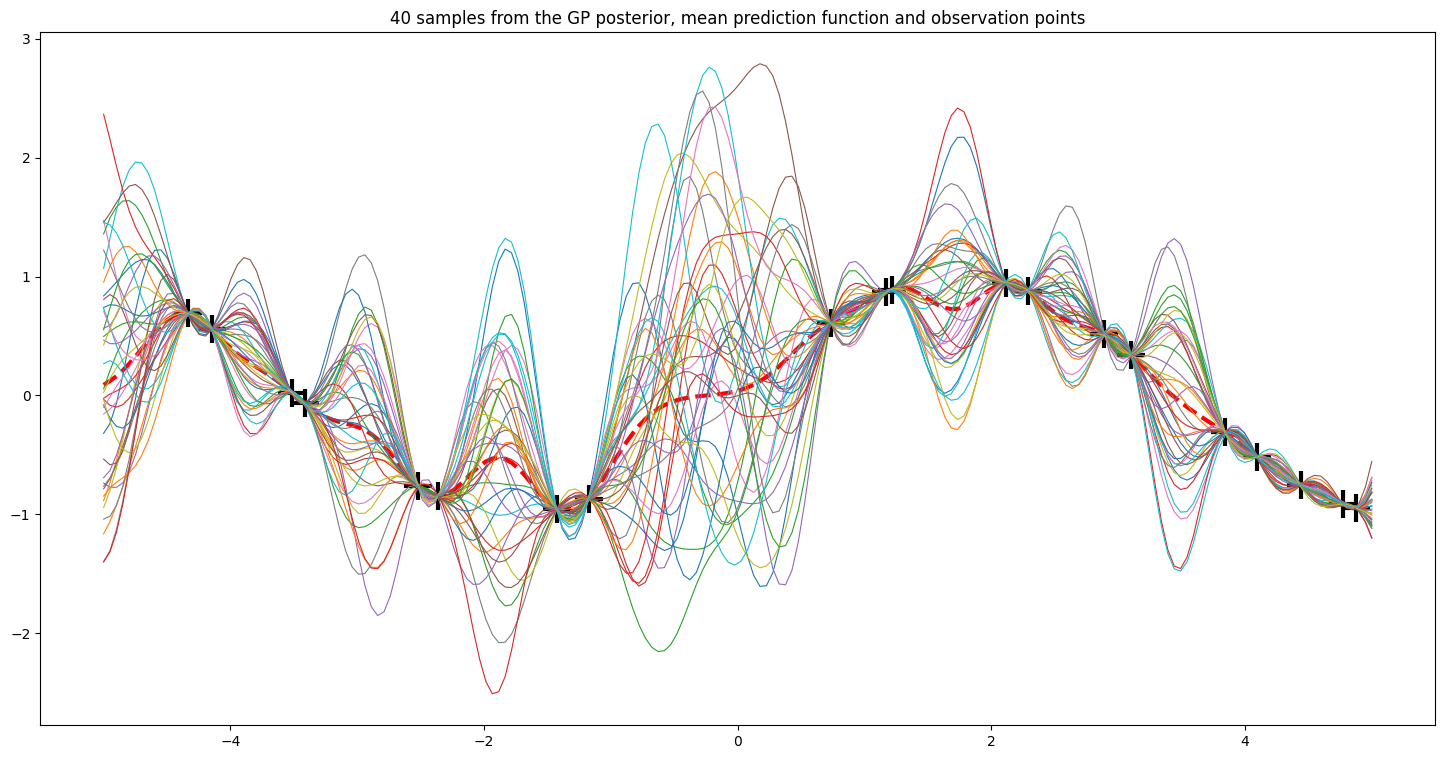

In [8]:
# draw samples from the posterior at our test points.
print(n)
print(N)
L = np.linalg.cholesky(K_ + 1e-6*np.eye(n) - np.dot(Lk.T, Lk))
f_post = mu.reshape(-1,1) + np.dot(L, np.random.normal(size=(n,40)))  # size=(n, m), m shown how many posterior  
plt.figure(3)
plt.clf()
plt.figure(figsize=(18,9))
plt.plot(X, y, 'k+', markersize=20, markeredgewidth=3)
plt.plot(Xtest, mu, 'r--', linewidth=3)
plt.plot(Xtest, f_post, linewidth=0.8)
plt.title('40 samples from the GP posterior, mean prediction function and observation points')
plt.show()
#plt.axis([-5, 5, -3, 3])
#plt.savefig('post.png', bbox_inches='tight', dpi=600)

We plotted `m=40` samples from the Gaussian Process posterior together with the mean function for prediction and the observation data points (training dataset). It's clear all posterior functions collapse at all observation points. 